## Test fetch

In [ ]:
import requests
url = "https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr.20260713/conus/hrrr.t00z.wrfsfcf00.grib2.idx"
print(requests.get(url, timeout=15).text)

In [ ]:
date = "20260713"
hh = "00"
fxx = "00"

base = f"https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr.{date}/conus/hrrr.t{hh}z.wrfsfcf{fxx}.grib2"
idx_url = base + ".idx"

lines = requests.get(idx_url, timeout=20).text.strip().split("\n")

# 8 m above ground = near-surface smoke
matches = [
    (i, line) for i, line in enumerate(lines)
    if "MASSDEN" in line or "8 m above ground" in line
]

print(f"found {len(matches)} candidate message(s):")
for i, line in matches:
    print(line)

found 1 candidate message(s):
76:44310940:d=2026071300:MASSDEN:8 m above ground:anl:


In [ ]:
idx, line = matches[0]  # message 76, MASSDEN, 8 m above ground

start = int(line.split(":")[1])
end = int(lines[idx + 1].split(":")[1]) - 1

headers = {"Range": f"bytes={start}-{end}"}
r = requests.get(base, headers=headers, timeout=60)

out_path = f"hrrr.{date}.t{hh}z.f{fxx}.smoke.grib2"
with open(out_path, "wb") as f:
    f.write(r.content)

print("saved", out_path, "size:", len(r.content), "bytes")

75 76:44310940:d=2026071300:MASSDEN:8 m above ground:anl:
44310940 44888658
saved hrrr.20260713.t00z.f00.smoke.grib2 size: 577719 bytes


In [ ]:
from pathlib import Path
from datetime import datetime
import pygrib

START = datetime(2026, 7, 13)
END   = datetime(2026, 7, 23)
FCST_HOUR = "00"  
OUTDIR = Path("hrrr_smoke_raw")
OUTDIR.mkdir(exist_ok=True)
g = pygrib.open(out_path).message(1)
print(g.typeOfLevel, g.level, g.parameterCategory, g.parameterNumber)
print("min/max:", g.values.min(), g.values.max())

## Download full MASSDEN data

In [ ]:
import requests
from pathlib import Path
from datetime import datetime, timedelta
import time

START = datetime(2026, 7, 13)
END   = datetime(2026, 7, 23)
FXX   = "00"  # forecast hour;
OUTDIR = Path("hrrr_smoke_raw")
OUTDIR.mkdir(exist_ok=True)

def get_massden_range(idx_url):
    lines = requests.get(idx_url, timeout=20).text.strip().split("\n")
    for i, line in enumerate(lines):
        if "MASSDEN" in line and "8 m above ground" in line:
            start = int(line.split(":")[1])
            end = int(lines[i + 1].split(":")[1]) - 1
            return start, end
    return None

log = []
date = START
while date <= END:
    ymd = date.strftime("%Y%m%d")
    for hh in range(24):
        hh_str = f"{hh:02d}"
        base = f"https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr.{ymd}/conus/hrrr.t{hh_str}z.wrfsfcf{FXX}.grib2"
        idx_url = base + ".idx"
        out_path = OUTDIR / f"hrrr.{ymd}.t{hh_str}z.f{FXX}.smoke.grib2"

        if out_path.exists():
            continue

        try:
            byte_range = get_massden_range(idx_url)
            if byte_range is None:
                log.append((ymd, hh_str, "MASSDEN not found in idx"))
                continue
            start, end = byte_range
            r = requests.get(base, headers={"Range": f"bytes={start}-{end}"}, timeout=60)
            with open(out_path, "wb") as f:
                f.write(r.content)
            log.append((ymd, hh_str, f"ok, {len(r.content)} bytes"))
        except Exception as e:
            log.append((ymd, hh_str, f"FAILED: {e}"))

        time.sleep(0.2)

    print(f"finished {ymd}")
    date += timedelta(days=1)

failed = [x for x in log if "FAILED" in x[2] or "not found" in x[2]]
print(f"\n{len(log) - len(failed)}/{len(log)} succeeded")
if failed:
    print("failures:")
    for f in failed:
        print(" ", f)

finished 20260713
finished 20260714
finished 20260715
finished 20260716
finished 20260717
finished 20260718
finished 20260719
finished 20260720
finished 20260721
finished 20260722
finished 20260723

264/264 succeeded


## loader

In [ ]:
import numpy as np
import xarray as xr
import re

RAW_DIR = Path("hrrr_smoke_raw")
files = sorted(RAW_DIR.glob("hrrr.*.smoke.grib2"))
print(f"found {len(files)} files")

found 264 files


In [9]:
def get_latlon(path):
    g = pygrib.open(str(path)).message(1)
    lats, lons = g.latlons()
    lons = np.where(lons > 180, lons - 360, lons)
    return lats, lons

lats0, lons0 = get_latlon(files[0])

# NYC bounding box (adjust as needed)
LAT_MIN, LAT_MAX = 40.30, 41.10
LON_MIN, LON_MAX = -74.50, -73.50

mask = (lats0 >= LAT_MIN) & (lats0 <= LAT_MAX) & (lons0 >= LON_MIN) & (lons0 <= LON_MAX)
rows, cols = np.where(mask)

# Bounding box in grid-index space (curvilinear grid → use index range, not the mask itself)
r0, r1 = rows.min(), rows.max() + 1
c0, c1 = cols.min(), cols.max() + 1

print(f"crop window: rows {r0}:{r1}, cols {c0}:{c1}  →  shape {(r1-r0, c1-c0)}")

lats_crop = lats0[r0:r1, c0:c1]
lons_crop = lons0[r0:r1, c0:c1]

crop window: rows 677:713, cols 1536:1571  →  shape (36, 35)


In [ ]:
def parse_timestamp(path):
    # filename pattern: hrrr.20260713.t00z.f00.smoke.grib2
    m = re.match(r"hrrr\.(\d{8})\.t(\d{2})z\.f(\d{2})\.smoke\.grib2", path.name)
    ymd, hh, fxx = m.groups()
    # For f00 (analysis), valid time == run time; 
    return datetime.strptime(f"{ymd}{hh}", "%Y%m%d%H")

records = []
failed = []

for f in files:
    try:
        g = pygrib.open(str(f)).message(1)
        vals = g.values[r0:r1, c0:c1].astype("float64") * 1e9  # kg/m³ → µg/m³
        ts = parse_timestamp(f)
        records.append((ts, vals))
    except Exception as e:
        failed.append((f.name, str(e)))

records.sort(key=lambda x: x[0])
print(f"loaded {len(records)} timesteps, {len(failed)} failed")
if failed:
    for name, err in failed:
        print(" ", name, err)

loaded 264 timesteps, 0 failed


In [11]:
times = [r[0] for r in records]
stack = np.stack([r[1] for r in records])  # shape: (time, y, x)

ds = xr.Dataset(
    data_vars={
        "smoke_ugm3": (["time", "y", "x"], stack),
    },
    coords={
        "time": times,
        "lat": (["y", "x"], lats_crop),
        "lon": (["y", "x"], lons_crop),
    },
)

print(ds)
print("value range across all hours:", float(ds.smoke_ugm3.min()), "→", float(ds.smoke_ugm3.max()))

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 264, y: 36, x: 35)
Coordinates:
  * time        (time) datetime64[us] 2kB 2026-07-13 ... 2026-07-23T23:00:00
    lat         (y, x) float64 10kB 40.35 40.35 40.34 ... 41.05 41.04 41.04
    lon         (y, x) float64 10kB -74.74 -74.7 -74.67 ... -73.32 -73.29 -73.25
Dimensions without coordinates: y, x
Data variables:
    smoke_ugm3  (time, y, x) float64 3MB 3.6 3.6 3.52 3.44 ... 0.24 0.24 0.24
value range across all hours: 0.06400129284802826 → 549.8400000000001


In [12]:
ds.to_netcdf("nyc_smoke_hourly.nc")
print("saved nyc_smoke_hourly.nc")

saved nyc_smoke_hourly.nc


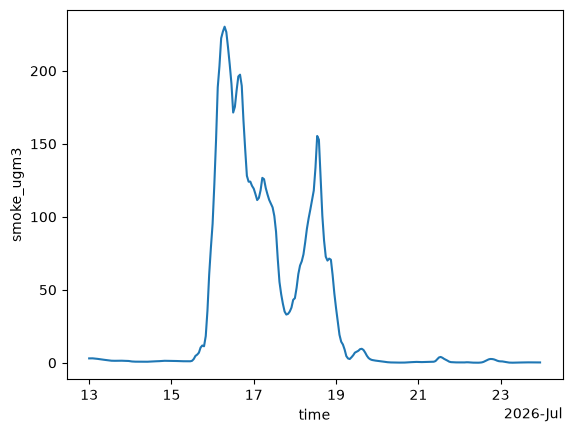

In [15]:
ds.smoke_ugm3.mean(dim=["y","x"]).plot()

## merge all 264 hours into one time-tagged GeoJSON

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import json
from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union

ds = xr.open_dataset("nyc_smoke_hourly.nc")
lats = ds["lat"].values
lons = ds["lon"].values

# EPA PM2.5 AQI-derived thresholds (µg/m³), collapsed to 4 health categories
LEVEL_BOUNDS = [0, 9, 35.4, 125.4]
LEVEL_NAMES = ["clear", "low", "medium", "high"]

all_features = []
empty_hours = []

for hour_index, t in enumerate(ds.time.values):
    vals = ds.smoke_ugm3.isel(time=hour_index).values
    vals_clean = np.nan_to_num(vals)

    # contourf needs a finite top edge; extend past this hour's actual max
    # so the top band always captures everything above the last threshold
    top = max(LEVEL_BOUNDS[-1] + 1, float(np.nanmax(vals_clean)) + 1)
    contour_levels = LEVEL_BOUNDS + [top]

    cs = plt.contourf(lons, lats, vals_clean, levels=contour_levels)
    plt.close()

    t = str(t)[:16]
    hour_had_features = False

    for i, path in enumerate(cs.get_paths()):
        polys = [Polygon(p) for p in path.to_polygons() if len(p) >= 4]
        if not polys:
            continue
        geom = unary_union(polys).simplify(0.001)

        lo, hi = contour_levels[i], contour_levels[i + 1]
        band_mask = (vals_clean >= lo) & (vals_clean < hi)
        if not np.any(band_mask):
            continue

        band_mean = float(vals_clean[band_mask].mean())
        hour_had_features = True

        all_features.append({
            "type": "Feature",
            "properties": {
                "hour_index": hour_index,
                "time": t,
                "smoke_mean_ugm3": round(band_mean, 4),
                "smoke_level": LEVEL_NAMES[i],
            },
            "geometry": mapping(geom),
        })

    if not hour_had_features:
        empty_hours.append(hour_index)

geojson = {"type": "FeatureCollection", "features": all_features}

with open("nyc_smoke_all_hours_levels.geojson", "w") as f:
    json.dump(geojson, f)

print(f"wrote {len(all_features)} total features across {ds.dims['time']} hours")
if empty_hours:
    print(f"{len(empty_hours)} hour(s) had no smoke above the lowest band: {empty_hours[:10]}{'...' if len(empty_hours) > 10 else ''}")

wrote 433 total features across 264 hours


/var/folders/xf/0d4mjb4n1_s2fryxg2crrv0r0000gn/T/ipykernel_52505/475593875.py:67: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"wrote {len(all_features)} total features across {ds.dims['time']} hours")
